# Hierarchical Clustering

**Hierarchical Clustering** is an **unsupervised machine learning algorithm** that groups similar data points by building a **hierarchy (tree) of clusters**.

Unlike **K-Means**, which directly divides the data into **K clusters**, Hierarchical Clustering gradually builds clusters and allows us to see the relationships between them.

The final output is a **tree-like diagram called a Dendrogram**, which helps us decide how many clusters naturally exist in the data.

---

# 1. Why Do We Need Hierarchical Clustering?

Although K-Means is simple and fast, it has some limitations.

- We must specify the number of clusters (**K**) before training.
- It works best when clusters are roughly circular or spherical.
- It is sensitive to outliers.
- It doesn't show relationships between clusters.

Hierarchical Clustering overcomes some of these limitations by building a hierarchy of clusters instead of creating only one fixed partition.

---

# 2. Types of Hierarchical Clustering

There are two approaches.

## A. Agglomerative Clustering (Bottom-Up)

This is the most commonly used approach.

It starts with:

```
Every data point is its own cluster.
```

Then,

- Find the two closest clusters.
- Merge them.
- Repeat this process.

Eventually,

all data points become one large cluster.

```
Start

A   B   C   D   E

↓

(A B)   C   D   E

↓

(A B C)   D   E

↓

(A B C D)   E

↓

(A B C D E)
```

---

## B. Divisive Clustering (Top-Down)

This works in the opposite direction.

It starts with:

```
All data points in one cluster.
```

Then repeatedly splits the cluster into smaller clusters until every point becomes its own cluster.

```
ABCDE

↓

ABC    DE

↓

AB    C    DE

↓

A    B    C    D    E
```

Divisive clustering is rarely used because it is computationally expensive.

---

# 3. How Agglomerative Clustering Works

Since Agglomerative Clustering is the most popular method, let's understand its workflow.

---

## Step 1: Treat Every Point as a Separate Cluster

Suppose we have five data points.

Initially,

```
A

B

C

D

E
```

There are **5 clusters**.

---

## Step 2: Measure Distance Between Clusters

The algorithm calculates how close every cluster is to every other cluster.

Initially, each cluster contains only one point.

So it simply measures the distance between individual data points.

---

## Step 3: Merge the Closest Clusters

The closest two clusters are merged.

For example,

if

```
A and B
```

are the closest,

they become

```
(A,B)
```

Now the total number of clusters decreases by one.

---

## Step 4: Update Distances

Since a new cluster has been created,

the algorithm recalculates distances between this new cluster and all remaining clusters.

---

## Step 5: Repeat

The algorithm keeps repeating:

```
Find closest clusters

↓

Merge them

↓

Update distances

↓

Repeat
```

until all data points belong to one large cluster.

---

# 4. Linkage Methods

A very important question arises after merging.

Suppose

Cluster A has many points.

Cluster B also has many points.

How do we measure the distance between these two clusters?

Different answers lead to different **Linkage Methods**.

---

## A. Single Linkage

Single Linkage looks at the **closest pair of points** between two clusters.

Imagine two groups of people.

It asks:

> "What is the shortest distance between any person in Group A and any person in Group B?"

If that shortest distance is small,

the clusters are merged.

### Characteristics

- Good for irregular-shaped clusters.
- Can create long chain-like clusters.
- Sensitive to noise.

---

## B. Complete Linkage

Instead of the closest points,

Complete Linkage looks at the **farthest pair of points**.

It asks:

> "What is the maximum distance between any point in Cluster A and Cluster B?"

### Characteristics

- Produces compact clusters.
- Less affected by chaining.
- Can split naturally large clusters.

---

## C. Average Linkage

Instead of minimum or maximum,

Average Linkage computes the **average distance** between all pairs of points.

Think of it as finding the average friendship distance between two groups.

### Characteristics

- Balanced approach.
- Less sensitive to noise.
- Often performs better than Single Linkage.

---

## D. Ward's Linkage

Ward's Linkage works differently.

Instead of directly comparing distances,

it asks:

> "If these two clusters are merged, how much will the cluster become less compact?"

It always chooses the merge that increases the cluster variation the least.

### Characteristics

- Produces compact clusters.
- Most commonly used.
- Often gives results similar to K-Means.

---

# 5. Dendrogram

The most unique feature of Hierarchical Clustering is the **Dendrogram**.

A dendrogram is simply a **tree diagram** showing how clusters were merged.

Example:

```
          ───────
         |       |
     ────        |
    |   |        |
   A    B      ────
               |  |
               C  ───
                  | |
                  D E
```

The bottom contains the original data points.

As we move upward,

clusters merge together.

The top represents one giant cluster containing all points.

---

# 6. Choosing the Number of Clusters

Unlike K-Means,

Hierarchical Clustering does **not** require choosing K beforehand.

Instead,

we use the dendrogram.

Imagine drawing a horizontal line across the dendrogram.

```
        |
     ---|--------
        |
```

Count how many vertical branches this line cuts.

That number becomes the number of clusters.

Example:

If the horizontal line cuts

```
3
```

branches,

then

```
K = 3
```

---

# 7. Advantages

- No need to specify K initially.
- Produces a hierarchy of clusters.
- Easy to visualize using a dendrogram.
- Can discover nested cluster structures.

---

# 8. Limitations

- Computationally expensive.
- Not suitable for very large datasets.
- Once two clusters are merged, the decision cannot be undone.
- Sensitive to the choice of linkage method.

---

# 9. When Should You Use Hierarchical Clustering?

Use Hierarchical Clustering when:

- The dataset is relatively small.
- You don't know the number of clusters.
- You want to visualize relationships between clusters.
- You want a dendrogram for interpretation.

Use K-Means when:

- The dataset is large.
- You already know K.
- Speed is important.

---

# 10. Summary

| Concept | Description |
|---------|-------------|
| Learning Type | Unsupervised Learning |
| Goal | Build a hierarchy of similar clusters |
| Most Common Method | Agglomerative Clustering |
| Starting Point | Every point is its own cluster |
| Process | Merge nearest clusters repeatedly |
| Final Output | Dendrogram |
| Choosing K | Draw a horizontal line on the dendrogram and count the branches it intersects |

---

# Overall Workflow

```text
            Unlabeled Dataset
                    │
                    ▼
      Treat Every Point as One Cluster
                    │
                    ▼
      Find the Two Closest Clusters
                    │
                    ▼
          Merge Those Clusters
                    │
                    ▼
         Update Cluster Distances
                    │
                    ▼
          More Than One Cluster?
             │             │
           Yes            No
             │             │
             └────────────► Build Dendrogram
                              │
                              ▼
                  Choose Number of Clusters
```

In [3]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 

In [4]:
customer_data = pd.read_csv('hierarchical-clustering-with-python-and-scikit-learn-shopping-data.csv')

In [5]:
customer_data.shape

(200, 5)

In [6]:
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# lets use only Annual Income (k$)	Spending Score (1-100) cols for this excerice 
data = customer_data.iloc[:, 3:5].values

In [8]:
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

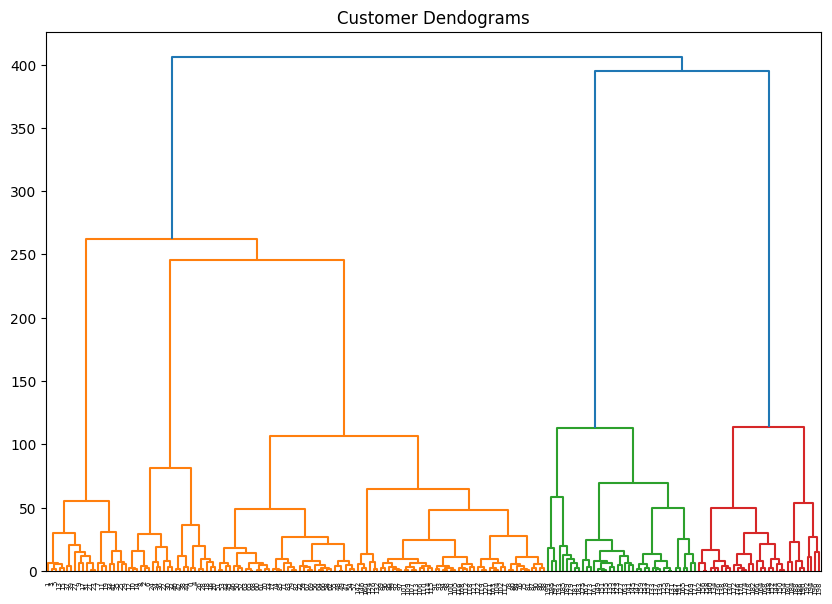

In [9]:
import scipy.cluster.hierarchy as sch 

plt.figure(figsize=(10,7)) 
plt.title('Customer Dendograms')
dend = sch.dendrogram(sch.linkage(data,method='ward'))

In [10]:
# now lets run the algo , as we see in he dendogramn we can have 5 clusters 

from sklearn.cluster import AgglomerativeClustering 

cls = AgglomerativeClustering(n_clusters=5,
                             metric='euclidean',
                              linkage='complete')   # initials modle 

lables_ = cls.fit_predict(data)   # train & predict

In [12]:
# Values ( no of cluster assigned to each value from (0-4 clusters))
lables_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0])

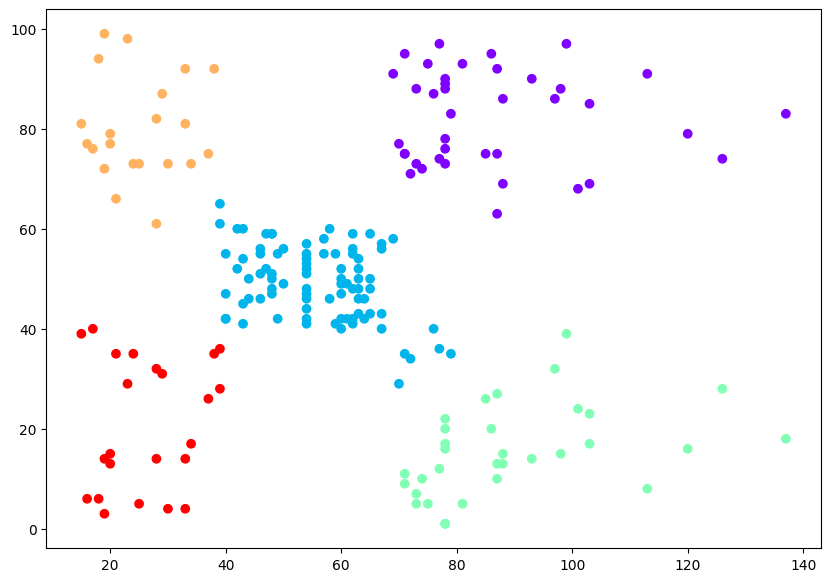

In [14]:
# Lets visualise them
plt.figure(figsize=(10, 7))
plt.scatter(data[:,0], data[:,1], c=cls.labels_, cmap='rainbow')